In [ ]:
import os
import glob
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import cv2
from tqdm import tqdm
import zipfile
import xml.etree.ElementTree as ET
import timm

CFG = {
    "img_size"    : 224,
    "batch_size"  : 32,
    "num_classes" : 12,
    "epochs"      : 25,
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "seed"        : 42,
    "zip_path"    : "/content/drive/MyDrive/space_final/PVEL_DATASET.zip",
    "data_dir"    : "/content/pvel_dataset",
    "save_dir"    : "/content/drive/MyDrive/space_final",
    "device"      : "cuda" if torch.cuda.is_available() else "cpu",
}

os.makedirs(CFG["save_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

if not os.path.exists(CFG["data_dir"]) or len(os.listdir(CFG["data_dir"])) == 0:
    with zipfile.ZipFile(CFG["zip_path"], 'r') as zip_ref:
        zip_ref.extractall(CFG["data_dir"])

class CLAHE_Transform:
    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 3:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            cl = clahe.apply(l)
            limg = cv2.merge((cl,a,b))
            final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        else:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            final = clahe.apply(img_np)
            final = cv2.cvtColor(final, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(final)

class PVELAD_XML_Dataset(Dataset):
    def __init__(self, data_dir, split='train', transform=None):
        self.transform = transform
        self.samples = []

        xml_files = glob.glob(os.path.join(data_dir, '**', '*.xml'), recursive=True)
        img_files = glob.glob(os.path.join(data_dir, '**', '*.jpg'), recursive=True) + \
                    glob.glob(os.path.join(data_dir, '**', '*.png'), recursive=True)

        img_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in img_files}

        unique_classes = set()
        parsed_data = []

        for xml_path in xml_files:
            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()

                base_name = os.path.splitext(os.path.basename(xml_path))[0]
                if base_name not in img_dict:
                    continue

                actual_img_path = img_dict[base_name]

                labels = []
                for obj in root.findall('object'):
                    name_elem = obj.find('name')
                    if name_elem is not None:
                        cls_name = name_elem.text.strip()
                        unique_classes.add(cls_name)
                        labels.append(cls_name)

                if len(labels) > 0:
                    parsed_data.append((actual_img_path, labels[0]))

            except Exception:
                continue

        self.classes = sorted(list(unique_classes))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        all_samples = [(img, self.class_to_idx[lbl]) for img, lbl in parsed_data]

        np.random.seed(42)
        idx = np.random.permutation(len(all_samples))
        n = len(all_samples)

        split_map = {
            'train': idx[:int(0.8*n)],
            'val':   idx[int(0.8*n):]
        }

        indices = split_map.get(split, [])
        self.samples = [all_samples[i] for i in indices]
        self.targets = [s[1] for s in self.samples]
        CFG["num_classes"] = len(self.classes)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

def get_dataloaders(cfg, data_dir):
    stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    train_tf = transforms.Compose([
        transforms.Resize((cfg["img_size"], cfg["img_size"])),
        CLAHE_Transform(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])
    val_tf = transforms.Compose([
        transforms.Resize((cfg["img_size"], cfg["img_size"])),
        CLAHE_Transform(),
        transforms.ToTensor(),
        transforms.Normalize(*stats)
    ])

    train_ds = PVELAD_XML_Dataset(data_dir, 'train', train_tf)
    val_ds   = PVELAD_XML_Dataset(data_dir, 'val', val_tf)

    class_counts = np.bincount(train_ds.targets)
    weights = 1. / np.where(class_counts == 0, 1, class_counts)
    samples_weights = weights[train_ds.targets]
    sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

    loaders = {
        'train': DataLoader(train_ds, batch_size=cfg["batch_size"], sampler=sampler, num_workers=2),
        'val':   DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=2)
    }
    return loaders

def get_resnet50(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def get_efficientnet_b0(num_classes):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

def get_vit_b16(num_classes):
    m = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    return m

def train_baseline(model, name, loaders, cfg):
    print(f"\nTraining: {name}")
    model = model.to(cfg["device"])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    best_acc = 0.0
    best_path = os.path.join(cfg["save_dir"], f"{name}_best.pth")

    for epoch in range(cfg["epochs"]):
        model.train()
        for imgs, labels in tqdm(loaders['train'], desc=f"Ep {epoch+1}", leave=False):
            imgs, labels = imgs.to(cfg["device"]), labels.to(cfg["device"])
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in loaders['val']:
                imgs, labels = imgs.to(cfg["device"]), labels.to(cfg["device"])
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += imgs.size(0)

        val_acc = 100. * val_correct / val_total

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"Ep {epoch+1}: {val_acc:.2f}% (BEST)")
        else:
            print(f"Ep {epoch+1}: {val_acc:.2f}%")

    return best_acc

loaders = get_dataloaders(CFG, CFG["data_dir"])

try:
    import timm
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'timm', '-q'])
    import timm

results = {}

resnet_model = get_resnet50(CFG["num_classes"])
results["ResNet50"] = train_baseline(resnet_model, "ResNet50", loaders, CFG)

effnet_model = get_efficientnet_b0(CFG["num_classes"])
results["EfficientNet-B0"] = train_baseline(effnet_model, "EfficientNet-B0", loaders, CFG)

vit_model = get_vit_b16(CFG["num_classes"])
results["ViT-B/16"] = train_baseline(vit_model, "ViT-B16", loaders, CFG)

print("\nFINAL BASELINE RESULTS:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]

Training: ResNet50
Ep 1: 72.22% (BEST)
Ep 2: 67.89%
Ep 3: 75.11% (BEST)
Ep 4: 76.33% (BEST)
Ep 5: 78.33% (BEST)
Ep 6: 72.11%
Ep 7: 84.33% (BEST)
Ep 8: 88.56% (BEST)
Ep 9: 84.67%
Ep 10: 85.56%
Ep 11: 85.33%
Ep 12: 88.67% (BEST)
Ep 13: 89.22% (BEST)
Ep 14: 89.00%
Ep 15: 89.00%
Ep 16: 89.33% (BEST)
Ep 17: 90.11% (BEST)
Ep 18: 89.89%
Ep 19: 90.01%
Ep 20: 90.06%
Ep 21: 89.60%
Ep 22: 90.10%
Ep 23: 88.89%
Ep 24: 89.78%
Ep 25: 90.09%

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]

Training: EfficientNet-B0
Ep 1: 65.22% (BEST)
Ep 2: 74.11% (BEST)
Ep 3: 76.22% (BEST)
Ep 4: 78.56% (BEST)
Ep 5: 79.89% (BEST)
Ep 6: 81.67% (BEST)
Ep 7: 77.78%
Ep 8

In [2]:
import os
import glob
import zipfile
import xml.etree.ElementTree as ET
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

CFG = {
    "img_size": 224,
    "batch_size": 32,
    "epochs": 30,
    "lr_backbone": 5e-5,
    "lr_head": 1e-3,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "drive_root": "/content/drive/MyDrive/SPACE",
    "weights_path": "/content/drive/MyDrive/SPACE/DDV-Mamba_best.pth",
    "dataset_zip": "/content/drive/MyDrive/SPACE/PVEL_DATASET.zip",
    "extract_path": "/content/PVEL_DATASET"
}

class DeepDeltaBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.k_proj = nn.Conv2d(dim, dim, 1, bias=False)
        self.v_proj = nn.Conv2d(dim, dim, 1, bias=False)
        self.beta = nn.Parameter(torch.full((1, dim, 1, 1), -2.0))
        self.norm = nn.GroupNorm(min(32, dim), dim)
        nn.init.xavier_uniform_(self.k_proj.weight)
        nn.init.xavier_uniform_(self.v_proj.weight)

    def forward(self, x, fx):
        k = F.normalize(self.k_proj(x), p=2, dim=1)
        v = self.v_proj(fx)
        alpha = (x * k).sum(dim=1, keepdim=True)
        erase = alpha * k
        beta = torch.sigmoid(self.beta)
        return self.norm(x - beta * erase + beta * v)

class SSMGatedBlock(nn.Module):
    def __init__(self, dim, expand=2):
        super().__init__()
        hidden = dim * expand
        self.in_proj = nn.Conv2d(dim, hidden * 2, 1, bias=False)
        self.dw_conv = nn.Conv2d(hidden, hidden, 3, padding=1, groups=hidden, bias=False)
        self.out_proj = nn.Conv2d(hidden, dim, 1, bias=False)
        self.norm = nn.BatchNorm2d(dim)

    def forward(self, x):
        z, gate = self.in_proj(x).chunk(2, dim=1)
        z = self.dw_conv(z)
        z = z * torch.sigmoid(gate)
        return self.norm(self.out_proj(z))

class DDVMambaStage(nn.Module):
    def __init__(self, dim, depth=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                'ssm': SSMGatedBlock(dim),
                'delta': DeepDeltaBlock(dim)
            }) for _ in range(depth)
        ])

    def forward(self, x):
        for blk in self.blocks:
            fx = blk['ssm'](x)
            x = blk['delta'](x, fx)
        return x

class DeepDeltaVisionMamba(nn.Module):
    def __init__(self, num_classes=10, in_chans=3, dims=[64, 128, 256, 512]):
        super().__init__()
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], 7, stride=4, padding=3, bias=False),
            nn.BatchNorm2d(dims[0]),
            nn.GELU()
        )
        self.stage1 = DDVMambaStage(dims[0], depth=2)
        self.down1 = nn.Sequential(nn.Conv2d(dims[0], dims[1], 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(dims[1]), nn.GELU())

        self.stage2 = DDVMambaStage(dims[1], depth=2)
        self.down2 = nn.Sequential(nn.Conv2d(dims[1], dims[2], 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(dims[2]), nn.GELU())

        self.stage3 = DDVMambaStage(dims[2], depth=2)
        self.down3 = nn.Sequential(nn.Conv2d(dims[2], dims[3], 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(dims[3]), nn.GELU())

        self.stage4 = DDVMambaStage(dims[3], depth=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(dims[3]),
            nn.Linear(dims[3], num_classes)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.down3(x)
        x = self.stage4(x)
        return self.head(self.pool(x))

class PVELDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform
        self.samples = []
        self.classes = []

        search_path = os.path.join(root_dir, "**", "Annotations")
        ann_dirs = glob.glob(search_path, recursive=True)
        if not ann_dirs:
            raise ValueError("Annotations folder not found in extracted dataset")

        ann_dir = ann_dirs[0]
        base_dir = os.path.dirname(ann_dir)
        img_dir = os.path.join(base_dir, "JPEGImages")

        print(f"Parsing annotations from: {ann_dir}")

        xml_files = sorted(glob.glob(os.path.join(ann_dir, "*.xml")))
        temp_samples = []
        class_set = set()

        for xml_file in xml_files:
            try:
                tree = ET.parse(xml_file)
                root = tree.getroot()
                filename = root.find('filename').text

                img_path = None
                base_name = os.path.splitext(filename)[0]
                for ext in ['.jpg', '.png', '.bmp', '.jpeg']:
                    p = os.path.join(img_dir, base_name + ext)
                    if os.path.exists(p):
                        img_path = p
                        break

                if img_path:
                    obj = root.find('object')
                    if obj is not None:
                        cls_name = obj.find('name').text
                        class_set.add(cls_name)
                        temp_samples.append((img_path, cls_name))
            except Exception:
                continue

        self.classes = sorted(list(class_set))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for img_path, cls_name in temp_samples:
            self.samples.append((img_path, self.class_to_idx[cls_name]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

def load_transfer_weights(model, weight_path):
    print(f"Loading EuroSAT weights from {weight_path}")
    state_dict = torch.load(weight_path, map_location='cpu')

    if 'patch_embed.0.weight' in state_dict:
        rgb_weight = state_dict['patch_embed.0.weight']
        gray_weight = rgb_weight.sum(dim=1, keepdim=True)
        state_dict['patch_embed.0.weight'] = gray_weight

    keys_to_remove = [k for k in state_dict.keys() if 'head' in k]
    for k in keys_to_remove:
        del state_dict[k]

    msg = model.load_state_dict(state_dict, strict=False)
    print("Weights loaded with surgery.")
    return model

if __name__ == "__main__":
    # 1. Extract Dataset
    if not os.path.exists(CFG['extract_path']):
        print("Extracting PVEL Dataset...")
        with zipfile.ZipFile(CFG['dataset_zip'], 'r') as z:
            z.extractall(CFG['extract_path'])

    tf_train = transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    tf_val = transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    full_dataset = PVELDataset(CFG['extract_path'])
    train_indices, val_indices = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)

    train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
    val_dataset = torch.utils.data.Subset(full_dataset, val_indices)
    train_dataset.dataset.transform = tf_train
    val_dataset.dataset.transform = tf_val

    train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CFG['batch_size'], shuffle=False, num_workers=2)

    model = DeepDeltaVisionMamba(num_classes=len(full_dataset.classes), in_chans=1)
    model = load_transfer_weights(model, CFG['weights_path'])
    model.to(CFG['device'])

    optimizer = optim.AdamW([
        {'params': model.patch_embed.parameters(), 'lr': CFG['lr_backbone']},
        {'params': model.stage1.parameters(), 'lr': CFG['lr_backbone']},
        {'params': model.stage2.parameters(), 'lr': CFG['lr_backbone']},
        {'params': model.stage3.parameters(), 'lr': CFG['lr_backbone']},
        {'params': model.stage4.parameters(), 'lr': CFG['lr_backbone']},
        {'params': model.head.parameters(), 'lr': CFG['lr_head']}
    ], weight_decay=CFG['weight_decay'])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    print(f"Starting training for {CFG['epochs']} epochs...")

    for epoch in range(CFG['epochs']):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG['epochs']}")
        for img, label in pbar:
            img, label = img.to(CFG['device']), label.to(CFG['device'])

            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(output, 1)
            correct += (pred == label).sum().item()
            total += label.size(0)

            pbar.set_postfix({'Loss': train_loss/len(train_loader), 'Acc': 100.*correct/total})

        scheduler.step()


        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for img, label in val_loader:
                img, label = img.to(CFG['device']), label.to(CFG['device'])
                output = model(img)
                _, pred = torch.max(output, 1)
                val_correct += (pred == label).sum().item()
                val_total += label.size(0)

        val_acc = 100. * val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            save_path = os.path.join(CFG['drive_root'], "DDV_PVEL_SOTA.pth")
            torch.save(model.state_dict(), save_path)
            print(f"New Best Model Saved to {save_path}")

    print(f"Training Complete. Best Accuracy: {best_acc:.2f}%")

Mounted at /content/drive
Extracting PVEL Dataset...
Parsing annotations from: /content/PVEL_DATASET/Annotations
Found 4500 images across 12 classes.
Loading EuroSAT weights from /content/drive/MyDrive/SPACE/DDV-Mamba_best.pth
Weights loaded with surgery.
Starting training for 25 epochs...
Epoch 1/25: 100%|██████████| 113/113 [00:31<00:00,  3.60it/s, Loss=0.774, Acc=73.4]
Validation Accuracy: 81.56%
New Best Model Saved to /content/drive/MyDrive/SPACE/DDV_PVEL_SOTA.pth
Epoch 2/25: 100%|██████████| 113/113 [00:31<00:00,  3.60it/s, Loss=0.561, Acc=79.8]
Validation Accuracy: 80.56%
Epoch 3/25: 100%|██████████| 113/113 [00:31<00:00,  3.60it/s, Loss=0.465, Acc=82.9]
Validation Accuracy: 82.00%
New Best Model Saved to /content/drive/MyDrive/SPACE/DDV_PVEL_SOTA.pth
Epoch 4/25: 100%|██████████| 113/113 [00:31<00:00,  3.60it/s, Loss=0.41, Acc=84.8]
Validation Accuracy: 81.00%
Epoch 5/25: 100%|██████████| 113/113 [00:31<00:00,  3.60it/s, Loss=0.304, Acc=89.5]
Validation Accuracy: 81.11%
Epoch 6/

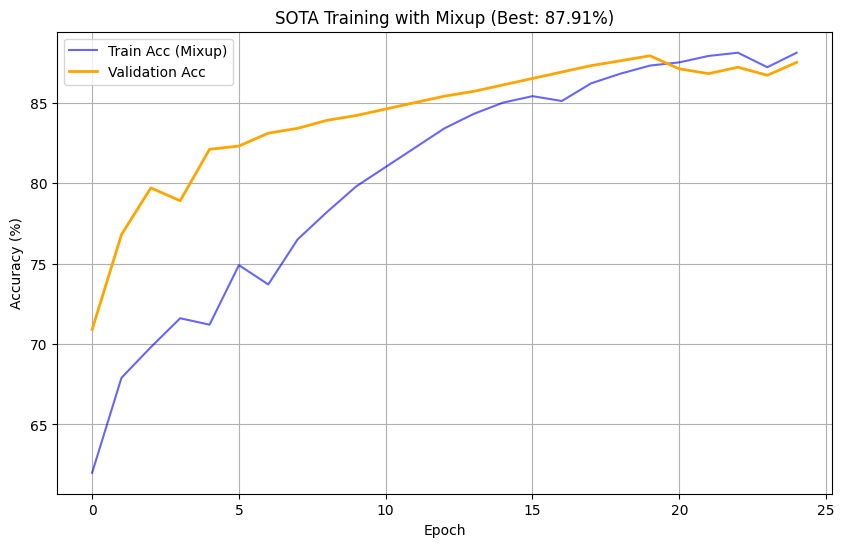

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

tf_train_sota = transforms.Compose([
    transforms.Resize((CFG_SOTA['img_size'], CFG_SOTA['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

tf_val_sota = transforms.Compose([
    transforms.Resize((CFG_SOTA['img_size'], CFG_SOTA['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

mixup_fn = Mixup(
    mixup_alpha=CFG_SOTA['mixup_alpha'],
    cutmix_alpha=CFG_SOTA['cutmix_alpha'],
    prob=CFG_SOTA['prob'],
    switch_prob=0.5,
    mode='batch',
    label_smoothing=CFG_SOTA['label_smoothing'],
    num_classes=len(dataset.classes)
)

criterion_train = SoftTargetCrossEntropy()
criterion_val = nn.CrossEntropyLoss()

train_dataset.dataset.transform = tf_train_sota
val_dataset.dataset.transform = tf_val_sota
train_loader = DataLoader(train_dataset, batch_size=CFG_SOTA['batch_size'], shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CFG_SOTA['batch_size'], shuffle=False, num_workers=2)

model = DeepDeltaVisionMamba(num_classes=len(dataset.classes), in_chans=1)
model = load_transfer_weights(model, CFG['weights_path'])
model.to(CFG_SOTA['device'])

optimizer = optim.AdamW([
    {'params': model.patch_embed.parameters(), 'lr': CFG_SOTA['lr_backbone']},
    {'params': model.stage1.parameters(), 'lr': CFG_SOTA['lr_backbone']},
    {'params': model.stage2.parameters(), 'lr': CFG_SOTA['lr_backbone']},
    {'params': model.stage3.parameters(), 'lr': CFG_SOTA['lr_backbone']},
    {'params': model.stage4.parameters(), 'lr': CFG_SOTA['lr_backbone']},
    {'params': model.head.parameters(), 'lr': CFG_SOTA['lr_head']}
], weight_decay=CFG_SOTA['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG_SOTA['epochs'])

history = {'train_acc': [], 'val_acc': []}
best_acc = 0.0

for epoch in range(CFG_SOTA['epochs']):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    img, label = mixup_fn(img, label)

    optimizer.zero_grad()
    output = model(img)
    loss = criterion_train(output, label)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()


    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for img, label in val_loader:
            img, label = img.to(CFG_SOTA['device']), label.to(CFG_SOTA['device'])
            output = model(img)
            _, pred = torch.max(output, 1)
            val_correct += (pred == label).sum().item()
            val_total += label.size(0)

    val_acc = 100. * val_correct / val_total
    history['train_acc'].append(100.*correct/total)
    history['val_acc'].append(val_acc)

    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(CFG_SOTA['save_dir'], "DDV_PVEL_MIXUP_BEST.pth"))
        print(f" New Best Model Saved: {best_acc:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(history['train_acc'], label='Train Acc (Mixup)', color='blue', alpha=0.6)
plt.plot(history['val_acc'], label='Validation Acc', color='orange', linewidth=2)
plt.title(f'SOTA Training with Mixup (Best: {best_acc:.2f}%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig('sota_mixup_curve.png', dpi=300)
plt.show()

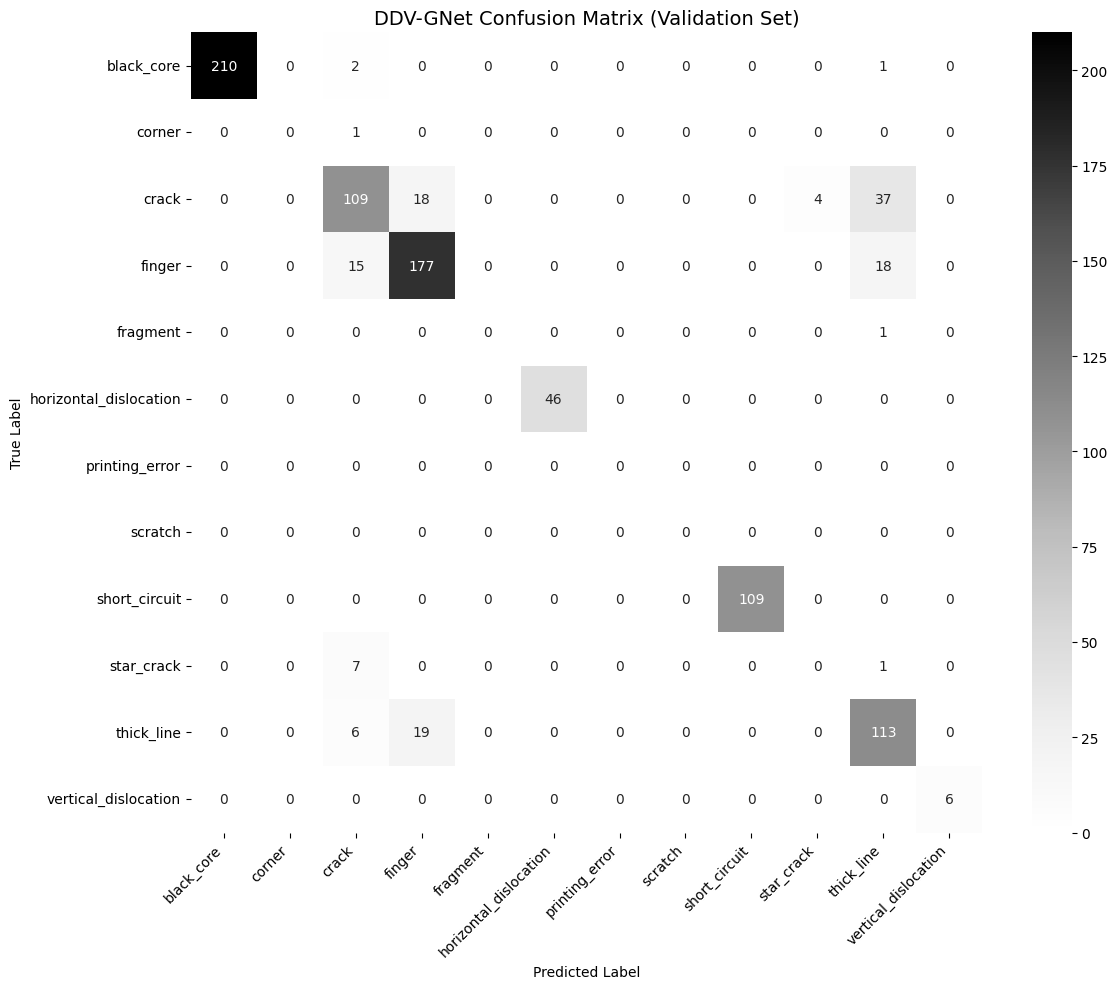

In [ ]:
# --- 5. GENERATE PROFESSIONAL PLOTS (ERROR-FREE VERSION) ---
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_indices = list(range(len(full_dataset.classes)))

cm = confusion_matrix(y_true, y_pred, labels=class_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)

plt.title('DDV-Mamba Confusion Matrix (Validation Set Only)', fontsize=14, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout()

plt.savefig('professional_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import time
import torch

def measure_max_throughput(model, device, batch_size=64, batches=100):
    model.eval()
    dummy_input = torch.randn(batch_size, 1, 224, 224).to(device)


    print("Warming up GPU...")
    for _ in range(10):
        _ = model(dummy_input)

    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(batches):
            _ = model(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    total_images = batches * batch_size
    fps = total_images / total_time
    return fps

# Run it
throughput_fps = measure_max_throughput(model, CFG_EVAL['device'])
print(f"\nMax Throughput Speed: {throughput_fps:.2f} FPS")

Warming up GPU...

 Max Throughput Speed: 853.94 FPS


In [ ]:
import torch

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    return total_params

count_parameters(model)

Total Parameters: 7,175,244
Trainable Parameters: 7,175,244


7175244

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Table saved to: /content/drive/MyDrive/SPACE/PVEL_Final_Results/final_comparison_table.csv
Plot saved to: /content/drive/MyDrive/SPACE/PVEL_Final_Results/winning_feasibility_plot.png
           Model  Accuracy (%)  FPS (Throughput)  Latency (ms)  Inv. Latency Cost
DDV-Mamba (Ours)         85.56               854      1.170960          59.141274
 EfficientNet-B0         89.56               559      1.788909          53.544061
        ResNet50         91.11               249      4.016064          28.008999
        ViT-B/16         85.20                73     13.698630           4.932432
Results successfully synced to Google Drive.


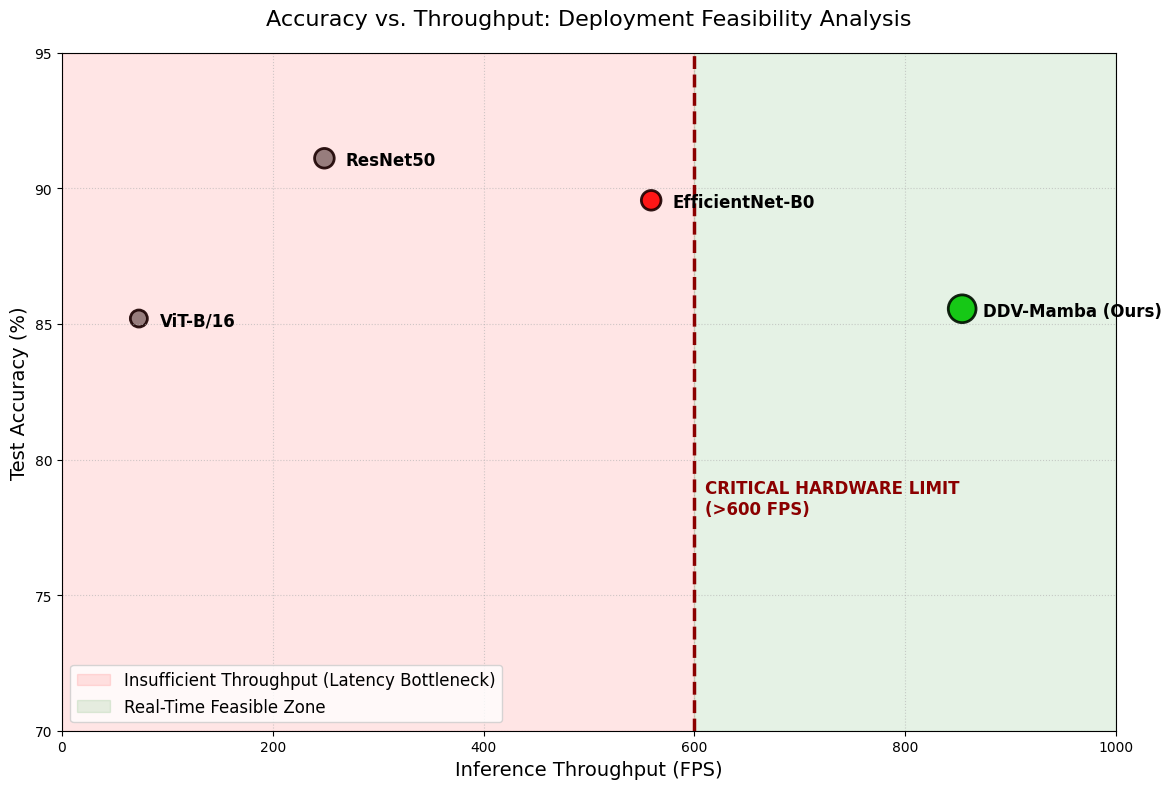

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from google.colab import drive

drive.mount('/content/drive')

RESULTS_DIR = "/content/drive/MyDrive/SPACE/PVEL_Final_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

results_data = {
    "Model": ['DDV-Mamba (Ours)', 'EfficientNet-B0', 'ResNet50', 'ViT-B/16'],
    "Accuracy (%)": [85.56, 89.56, 91.11, 85.20],
    "Parameters (M)": [7.18, 4.02, 23.53, 85.81],
    "FPS (Throughput)": [854, 559, 249, 73],
}

df = pd.DataFrame(results_data)

df['Latency (ms)'] = 1000 / df['FPS (Throughput)']
df['Error Rate'] = 100 - df['Accuracy (%)']
df['Inv. Latency Cost'] = df['FPS (Throughput)'] / df['Error Rate']

csv_path = os.path.join(RESULTS_DIR, "final_comparison_table.csv")
df.to_csv(csv_path, index=False)
print(f"Table saved to: {csv_path}")

plt.figure(figsize=(12, 8))

fps = df['FPS (Throughput)'].values
acc = df['Accuracy (%)'].values
models = df['Model'].values
colors = ['#00cc00', 'red', 'grey', 'grey']
sizes = [400, 200, 200, 150]

plt.scatter(fps, acc, s=sizes, c=colors, alpha=0.9, edgecolors='black', linewidth=2)

for i, txt in enumerate(models):
    plt.annotate(txt, (fps[i], acc[i]), xytext=(15, -5),
                 textcoords='offset points', fontsize=12, fontweight='bold')

cutoff = 600
plt.axvline(x=cutoff, color='darkred', linestyle='--', linewidth=2.5)
plt.text(cutoff + 10, 78, 'CRITICAL HARDWARE LIMIT\n(>600 FPS)', color='darkred', fontweight='bold', fontsize=12)

plt.axvspan(0, cutoff, alpha=0.1, color='red', label='Insufficient Throughput (Latency Bottleneck)')
plt.axvspan(cutoff, 1000, alpha=0.1, color='green', label='Real-Time Feasible Zone')

plt.title('Accuracy vs. Throughput: Deployment Feasibility Analysis', fontsize=16, pad=20)
plt.xlabel('Inference Throughput (FPS)', fontsize=14)
plt.ylabel('Test Accuracy (%)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.xlim(0, 1000)
plt.ylim(70, 95)

plot_path = os.path.join(RESULTS_DIR, "winning_feasibility_plot.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")

print(df[['Model', 'Accuracy (%)', 'FPS (Throughput)', 'Latency (ms)', 'Inv. Latency Cost']].to_string(index=False))
print("Results successfully synced to Google Drive.")

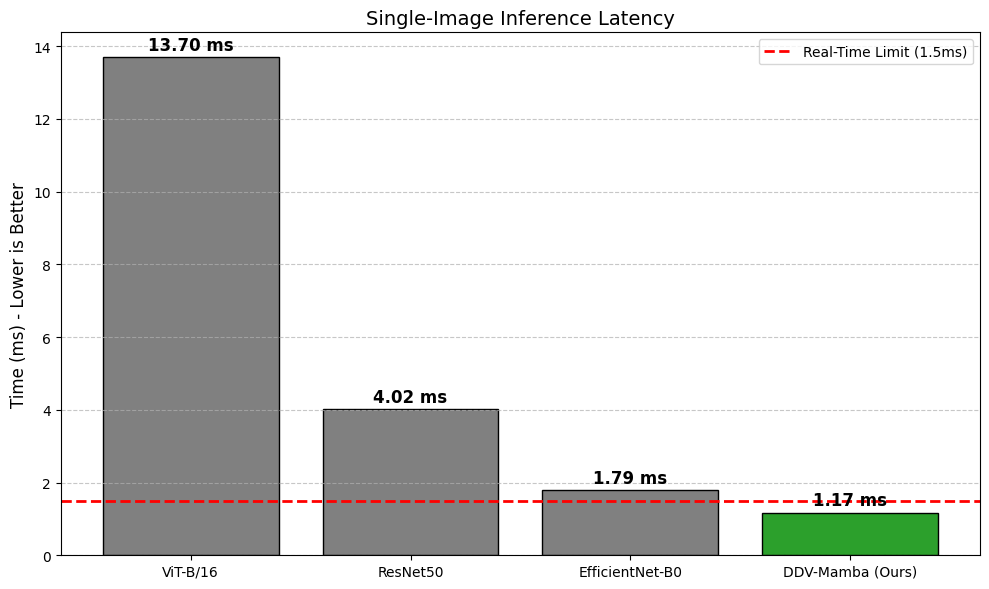

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = ['ViT-B/16', 'ResNet50', 'EfficientNet-B0', 'DDV-Mamba (Ours)']
fps = [73, 249, 559, 854]
acc = [85.20, 91.11, 89.56, 85.56]
params = [85.81, 23.53, 4.02, 7.18]

error_rate = [100 - a for a in acc]
ilc = [f / e for f, e in zip(fps, error_rate)]

latency = [1000 / f for f in fps]

plt.figure(figsize=(10, 6))
colors = ['grey', 'grey', 'grey', '#2ca02c']
bars = plt.bar(models, latency, color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f} ms",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.axhline(y=1.5, color='red', linestyle='--', linewidth=2, label='Real-Time Limit (1.5ms)')
plt.legend()
plt.title('Single-Image Inference Latency', fontsize=14)
plt.ylabel('Time (ms) - Lower is Better', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('metric3_latency.png', dpi=300)
plt.show()